# Tutorial 1: Differentially Private Medical Image Classification with DPDL

This notebook walks through using **DPDL** to train a classifier on **EyePACS** retinal fundus photographs with a [`timm`](https://github.com/huggingface/pytorch-image-models) model under **differential privacy (DP)**. 

Each shell step below is a `%%bash` cell (so it runs as a subprocess, the same as typing the commands in a terminal).
The bash commands can also be executed in another environment (e.g. terminal or SLURM job), which might be more suitable on compute clusters.
They are also provided as standalone scripts in the `tutorials/scripts/` folder as well.
The aggregation/analysis steps are plain Python cells using `pandas`/`matplotlib`, reading the result files, that DPDL writes to disk.

> **Note:** Training cells can take a long time. Add `--subset-size 0.05` to any
> `dpdl optimize` command below for a fast end-to-end check while you
> are getting the notebook working, then remove it for a real run.

A second tutorial/notebook, [`tutorial_hpo.ipynb`](tutorial_hpo.ipynb), builds on this one and covers DPDL's hyperparameter optimization tooling on the same dataset.

## Why differential privacy is relevant for tasks like this

EyePACS images are real clinical photographs collected for diabetic retinopathy (DR) screening. 
Unlike CIFAR-10-style benchmark photos, a model trained directly on this data can leak information about specific patients (e.g. via membership-inference or model-inversion attacks). 
Training with DP-SGD (as DPDL does by default) bounds how much any single patient's image can influence the final model, giving a formal, quantifiable privacy guarantee (`epsilon`). 
The epsilon sweep at the end of this notebook shows the privacy/utility trade-off, that has to be made when deploying these models.

## 1. Prerequisites

- Python >= 3.10
- A working PyTorch installation (CPU is fine for following along; a GPU will make the repeats/sweep sections much faster)
- An installation of DPDL in your kernel environment. If you haven't installed DPDL yet, see [the relevant section of the README](../README.md#install-from-source) for the `git clone` / `python -m venv` steps, then restart this notebook's kernel from inside
  that environment.

## 2. Verify the installation

Run the CPU test suite, which uses a tiny synthetic ("fake") dataset and
needs no downloads.

In [2]:
%%bash
cd ..
pip install -e ".[test]" -q
pytest -m "not gpu" -q

.....................                                                    [100%]
21 passed, 3 deselected in 234.42s (0:03:54)


If that finished without errors, the installation works and we can move on to real data.

## 3. A single training run on EyePACS

DPDL's entry point is the `dpdl` CLI (equivalently `python run.py`). The
general shape of a command is:

```
dpdl <command> [options...]
```

where `<command>` is one of `train`, `predict`, `train-predict`, `optimize`,
or `show-layers`. We'll use `train`.

For this tutorial we pick:

- **Dataset**: [`bumbledeep/eyepacs`](https://huggingface.co/datasets/bumbledeep/eyepacs)
   (a HuggingFace dataset id for the EyePACS dataset). DPDL downloads and caches it automatically the first time it's used. 
   It contains 35,108 macula-centered retinal photographs, each labeled with a diabetic retinopathy severity grade from 0 (no DR) to 4 (proliferative DR). It consists of a single `train` split,
  so DPDL automatically derives stratified validation/test splits (10% each, controlled by `--validation-size`/`--test-size`).
- **Model**: [`vit_tiny_patch16_224`](https://huggingface.co/docs/timm), which is an
  ImageNet-pretrained Vision Transformer available in `timm`. With ~5.7M parameters and a 224×224 input resolution it is a rather small model, but per-sample gradient computation under DP-SGD remains tractable on a laptop/CPU (set --subset-size 0.05 for quicker runs), while still resolving the fine spatial detail  (microaneurysms, hemorrhages, exudates) that retinal photographs require.

Relevant CLI argument options:

- `--dataset-label-field label_code`: tells DPDL to use the integer
  severity grade as the classification label, because otherwise the `label` field
  (a string) would get automatically determined and alphabetically encoded.
- `--metric-config conf/metrics/eyepacs.conf`: adds an AUROC metric
  (one-vs-rest, averaged) on top of the built-in accuracy metrics via a config file. AUROC is more informative than accuracy here because EyePACS (like a lot of medical circumstances) is imbalanced. See [conf/metrics/eyepacs.conf](conf/metrics/eyepacs.conf) and the "Custom metrics" section of [docs/trainer.md](docs/trainer.md).
- `--target-epsilon 8`: the privacy budget. DPDL derives the matching noise multiplier and a sensible `delta` (roughly `1/dataset_size`) automatically.

### 3.1 A quick look at EyePACS

Before training, let's load the dataset once and check its schema, class balance, and a few representative images. 
The dataset has only one published split, which is why we use DPDL to create the train/validation/test split later.

In [1]:
from datasets import load_dataset
from IPython.display import display
import pandas as pd

eyepacs = load_dataset("bumbledeep/eyepacs", split="train")
sample = eyepacs[0]

feature_summary = pd.DataFrame([
    {
        "feature": "image",
        "role": "model input",
        "dataset type": str(eyepacs.features["image"]),
        "example": f"{sample['image'].mode}, {sample['image'].width} x {sample['image'].height} pixels",
    },
    {
        "feature": "label_code",
        "role": "training target",
        "dataset type": str(eyepacs.features["label_code"]),
        "example": sample["label_code"],
    },
    {
        "feature": "label",
        "role": "human-readable target",
        "dataset type": str(eyepacs.features["label"]),
        "example": sample["label"],
    },
])

print(f"Published split: train ({len(eyepacs):,} images)")
feature_summary

Published split: train (35,108 images)


,feature,role,dataset type,example
0,image,model input,"Image(mode=None, decode=True)","RGB, 1024 x 1024 pixels"
1,label_code,training target,Value('int64'),0
2,label,human-readable target,Value('string'),no_diabetic_retinopathy


,grade,diagnosis,count,percent
0,0,no_diabetic_retinopathy,25802,73.5
2,1,mild_retinopathy,2438,6.9
1,2,moderate_retinopathy,5288,15.1
3,3,severe_retinopathy,872,2.5
4,4,proliferative_retinopathy,708,2.0


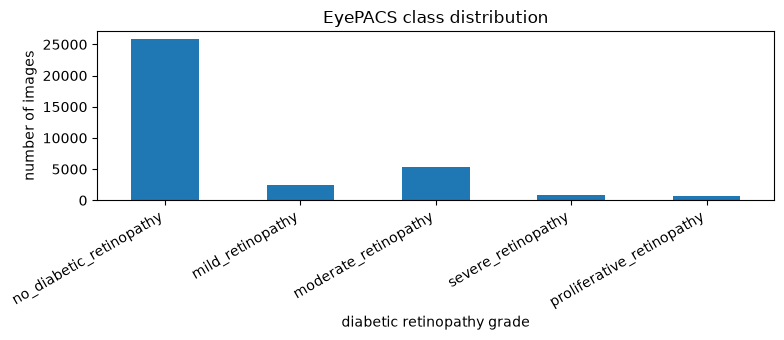

In [2]:
import matplotlib.pyplot as plt

labels = pd.DataFrame({
    "grade": eyepacs["label_code"],
    "diagnosis": eyepacs["label"],
})
class_distribution = (
    labels.value_counts(["grade", "diagnosis"])
    .rename("count")
    .reset_index()
    .sort_values("grade")
)
class_distribution["percent"] = (
    100 * class_distribution["count"] / len(eyepacs)
).round(1)
display(class_distribution)

ax = class_distribution.plot.bar(
    x="diagnosis", y="count", legend=False, figsize=(8, 3.5)
)
ax.set_xlabel("diabetic retinopathy grade")
ax.set_ylabel("number of images")
ax.set_title("EyePACS class distribution")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

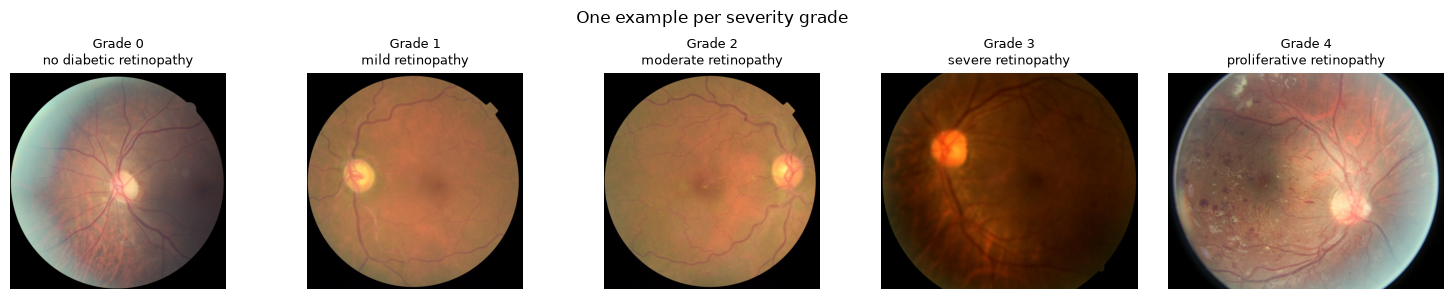

In [3]:
# Choose the first example of each grade without decoding every image.
representative_indices = {}
for index, grade in enumerate(eyepacs["label_code"]):
    representative_indices.setdefault(grade, index)
    if len(representative_indices) == 5:
        break

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for grade, ax in enumerate(axes):
    record = eyepacs[representative_indices[grade]]
    ax.imshow(record["image"])
    ax.set_title(f"Grade {grade}\n{record['label'].replace('_', ' ')}", fontsize=9)
    ax.axis("off")

fig.suptitle("One example per severity grade")
fig.tight_layout()
plt.show()

In [ ]:
%%bash
dpdl train \
    --dataset-name bumbledeep/eyepacs \
    --dataset-label-field label_code \
    --model-name vit_tiny_patch16_224 \
    --metric-config conf/metrics/eyepacs.conf \
    --epochs 5 \
    --batch-size 256 \
    --physical-batch-size 64 \
    --learning-rate 1e-3 \
    --target-epsilon 8 \
    --seed 0 \
    --device auto \
    --log-dir logs/tutorial \
    --experiment-name single_run \
    --overwrite-experiment

### 3.2 What gets written to disk

After the run finishes, `logs/tutorial/single_run/` contains everything
DPDL recorded about the run. Let's inspect it directly from Python.

In [ ]:
import json
from pathlib import Path

single_run_dir = Path("../logs/tutorial/single_run")

print("Files written:")
for p in sorted(single_run_dir.iterdir()):
    print(f"  {p.name}")

Files written:
  configuration.json
  configuration.txt
  final_epsilon
  git-hash
  gpu_count
  gpu_type
  hyperparameters.json
  hyperparameters.txt
  runtime
  stderr.txt
  stdout.txt
  test_metrics


In [7]:
test_metrics = json.loads((single_run_dir / "test_metrics").read_text())
final_epsilon = float((single_run_dir / "final_epsilon").read_text().strip())

print("test_metrics:")
for key, value in test_metrics.items():
    print(f"  {key}: {value}")

print(f"\nactual epsilon spent: {final_epsilon:.4f}")

test_metrics:
  ConfusionMatrix: [[2581, 0, 0, 0, 0], [244, 0, 0, 0, 0], [529, 0, 0, 0, 0], [87, 0, 0, 0, 0], [70, 0, 0, 0, 0]]
  MulticlassAccuracy: 0.20000000298023224
  MulticlassAccuracyPerClass: [1.0, 0.0, 0.0, 0.0, 0.0]
  MulticlassAccuracyWithMicro: 0.7351182103157043
  test_auroc: 0.6122392416000366
  loss: 1.8771525144577026

actual epsilon spent: 7.9941


`MulticlassAccuracy` is macro-averaged accuracy (the default metric for image classification tasks, accuracy over all samples regardless of class); `MulticlassAccuracyWithMicro` is the micro-averaged version (accuracy per class and then averaged); `AUROC` is the custom macro AUROC we added via `--metric-config`. 
Because EyePACS is heavily imbalanced towards "no DR", the micro-averaged accuracy can look much higher than the macro-averaged one purely as an artifact of class frequency. 
`final_epsilon` will be very close to, but not always exactly, the `--target-epsilon` we asked for.

There's also `runtime` (wall-clock training time), `configuration.json` / `hyperparameters.json` (a full record of every option used for the run), and `stdout.txt` / `stderr.txt` (captured logs). Please refer to [docs/experiment-directory.md](docs/experiment-directory.md) for the complete list. Let's confirm the configuration that was actually used:

In [8]:
configuration = json.loads((single_run_dir / "configuration.json").read_text())
hyperparameters = json.loads((single_run_dir / "hyperparameters.json").read_text())

import pandas as pd

pd.concat([
    pd.Series(configuration, name="configuration"),
    pd.Series(hyperparameters, name="hyperparameters"),
]).to_frame("value")

,value
command,train
privacy,True
model_name,vit_tiny_patch16_224
loss_function,CrossEntropyLoss
optimizer,Adam
...,...
max_grad_norm,1.0
target_epsilon,8.0
noise_batch_ratio,None
privacy,True


## 4. Running multiple repeats and computing mean/std

As DP training is noisy by design, a single run is even less indicative of overall performance, we need several independent runs of the same configuration, varying only the random seed, and then report the mean ± standard deviation of test metrics, being AUROC in our case.

The cell below is the training loop only and the analysis of the results is done in Python below. The command is executable in bash or in a SLURM job as is, so depending on your setup it might be worthwile to train outside of the notebook and just come back for the data analysis.

In [ ]:
%%bash
set -euo pipefail

# --- configuration shared by every run -------------------------------------
DATASET_NAME="bumbledeep/eyepacs"
LABEL_FIELD="label_code"
MODEL_NAME="vit_tiny_patch16_224"
METRIC_CONF="conf/metrics/eyepacs.conf"
EPOCHS=5
BATCH_SIZE=256
PHYSICAL_BATCH_SIZE=64
LEARNING_RATE=1e-3
TARGET_EPSILON=8
DEVICE="auto"
LOG_DIR="logs/tutorial"
SEEDS=(0 1 2 3 4)

for SEED in "${SEEDS[@]}"; do
    EXPERIMENT_NAME="eyepacs_vit_tiny_eps${TARGET_EPSILON}_seed${SEED}"

    echo "=== seed=${SEED} ==="

    dpdl train \
        --dataset-name "${DATASET_NAME}" \
        --dataset-label-field "${LABEL_FIELD}" \
        --model-name "${MODEL_NAME}" \
        --metric-config "${METRIC_CONF}" \
        --epochs "${EPOCHS}" \
        --batch-size "${BATCH_SIZE}" \
        --physical-batch-size "${PHYSICAL_BATCH_SIZE}" \
        --learning-rate "${LEARNING_RATE}" \
        --target-epsilon "${TARGET_EPSILON}" \
        --seed "${SEED}" \
        --device "${DEVICE}" \
        --log-dir "${LOG_DIR}" \
        --experiment-name "${EXPERIMENT_NAME}" \
        --overwrite-experiment
done

### 4.1 Aggregating the repeats

For the analysis we search the experiment directories for files that match
this run's naming pattern, read each one's `test_metrics`/`final_epsilon`
and finally compute mean/std test AUROC.

In [16]:
import json
from pathlib import Path

import pandas as pd

LOG_DIR = Path("../logs/tutorial")
TARGET_EPSILON = 8

result_dirs = sorted(LOG_DIR.glob(f"eyepacs_vit_tiny_eps{TARGET_EPSILON}_seed*"))

records = []
for result_dir in result_dirs:
    test_metrics = json.loads((result_dir / "test_metrics").read_text())
    final_epsilon = float((result_dir / "final_epsilon").read_text().strip())
    seed = int(result_dir.name.rsplit("seed", 1)[1])

    records.append({
        "seed": seed,
        "AUROC": test_metrics["AUROC"],
        "MulticlassAccuracy": test_metrics["MulticlassAccuracy"],
        "final_epsilon": final_epsilon,
    })

repeats_df = pd.DataFrame(records).sort_values("seed").reset_index(drop=True)
repeats_df

,seed,AUROC,MulticlassAccuracy,final_epsilon
0,0,0.718125,0.258137,7.998764
1,1,0.690412,0.216065,7.998764
2,2,0.697867,0.247218,7.998764
3,3,0.707812,0.236901,7.998764
4,4,0.712683,0.228801,7.998764


In [17]:
print(f"Runs:                  {len(repeats_df)}")
print(f"Mean test AUROC:        {repeats_df['AUROC'].mean():.4f}")
print(f"Std  test AUROC:        {repeats_df['AUROC'].std():.4f}")
print(f"Mean actual epsilon:    {repeats_df['final_epsilon'].mean():.4f}")

Runs:                  5
Mean test AUROC:        0.7054
Std  test AUROC:        0.0112
Mean actual epsilon:    7.9988


### 4.2 Extra analysis: visualizing the repeats

Beyond the mean/std it's worth looking at the distribution across seeds directly, because a small number of repeats can hide a skewed or bimodal distribution that a single mean/std pair would mask.

/tmp/ipykernel_130252/431059891.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(repeats_df["AUROC"], vert=True)


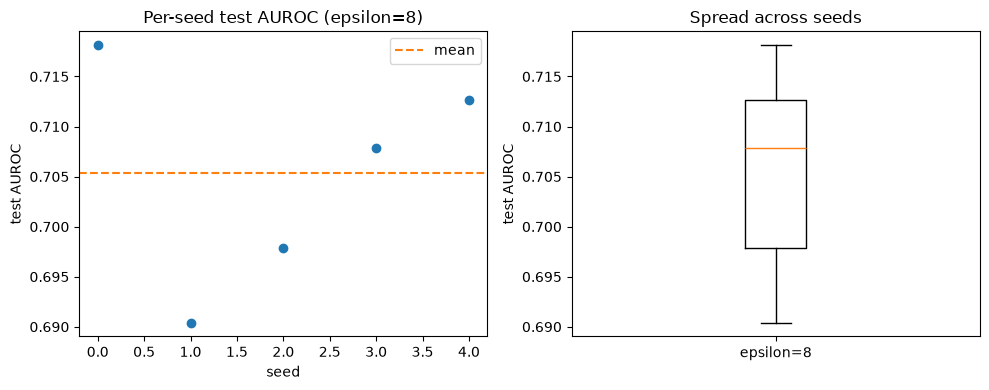

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(repeats_df["seed"], repeats_df["AUROC"])
axes[0].axhline(repeats_df["AUROC"].mean(), color="C1", linestyle="--", label="mean")
axes[0].set_xlabel("seed")
axes[0].set_ylabel("test AUROC")
axes[0].set_title(f"Per-seed test AUROC (epsilon={TARGET_EPSILON})")
axes[0].legend()

axes[1].boxplot(repeats_df["AUROC"], vert=True)
axes[1].set_xticklabels([f"epsilon={TARGET_EPSILON}"])
axes[1].set_ylabel("test AUROC")
axes[1].set_title("Spread across seeds")

fig.tight_layout()
plt.show()

## 5. Sweeping over multiple values of epsilon

Now let's see how the privacy/accuracy trade-off looks by repeating the process above for several `--target-epsilon` values. 
As in section 4, the cell below only runs the training loop (outer loop over epsilon, inner loop
over seeds). The aggregation/plotting happens in separate Python cells.

In [ ]:
%%bash
set -euo pipefail

DATASET_NAME="bumbledeep/eyepacs"
LABEL_FIELD="label_code"
MODEL_NAME="vit_tiny_patch16_224"
METRIC_CONF="conf/metrics/eyepacs.conf"
EPOCHS=2
BATCH_SIZE=256
PHYSICAL_BATCH_SIZE=64
LEARNING_RATE=1e-3
DEVICE="auto"
LOG_DIR="logs/tutorial_sweep"

EPSILONS=(1 3 5)
SEEDS=(0 1 2 3 4)

for EPSILON in "${EPSILONS[@]}"; do
    for SEED in "${SEEDS[@]}"; do
        EXPERIMENT_NAME="eyepacs_vit_tiny_eps${EPSILON}_seed${SEED}"

        echo "=== epsilon=${EPSILON}, seed=${SEED} ==="

        dpdl train \
            --dataset-name "${DATASET_NAME}" \
            --dataset-label-field "${LABEL_FIELD}" \
            --model-name "${MODEL_NAME}" \
            --metric-config "${METRIC_CONF}" \
            --epochs "${EPOCHS}" \
            --batch-size "${BATCH_SIZE}" \
            --physical-batch-size "${PHYSICAL_BATCH_SIZE}" \
            --learning-rate "${LEARNING_RATE}" \
            --target-epsilon "${EPSILON}" \
            --seed "${SEED}" \
            --device "${DEVICE}" \
            --log-dir "${LOG_DIR}" \
            --experiment-name "${EXPERIMENT_NAME}" \
            --overwrite-experiment
    done
done

(Optional) A non-private baseline (`--no-privacy`) for comparison. 
Note there's no `final_epsilon` file for this run, since epsilon is not observed without DP:

In [ ]:
%%bash
set -euo pipefail

dpdl train \
    --dataset-name bumbledeep/eyepacs \
    --dataset-label-field label_code \
    --model-name vit_tiny_patch16_224 \
    --metric-config conf/metrics/eyepacs.conf \
    --epochs 5 \
    --batch-size 256 \
    --physical-batch-size 64 \
    --learning-rate 1e-3 \
    --no-privacy \
    --seed 0 \
    --device auto \
    --log-dir logs/tutorial_sweep \
    --experiment-name eyepacs_vit_tiny_no_privacy_seed0 \
    --overwrite-experiment

### 5.1 Aggregating the sweep

Glob every `(epsilon, seed)` experiment directory, read its metrics, and
group by the requested epsilon (we also keep the actual epsilon spent,
for a sanity check against the accountant's rounding).

In [19]:
import re
from pathlib import Path

import pandas as pd

SWEEP_LOG_DIR = Path("../logs/tutorial_sweep")
PATTERN = re.compile(r"eyepacs_vit_tiny_eps(?P<epsilon>[\w.]+)_seed(?P<seed>\d+)$")

records = []
for result_dir in sorted(SWEEP_LOG_DIR.iterdir()):
    match = PATTERN.match(result_dir.name)
    if not match or not (result_dir / "test_metrics").exists():
        continue

    test_metrics = json.loads((result_dir / "test_metrics").read_text())
    final_epsilon_path = result_dir / "final_epsilon"
    actual_epsilon = (
        float(final_epsilon_path.read_text().strip())
        if final_epsilon_path.exists()
        else float("nan")  # no-privacy runs don't write this file
    )

    records.append({
        "target_epsilon": match.group("epsilon"),
        "seed": int(match.group("seed")),
        "AUROC": test_metrics["AUROC"],
        "MulticlassAccuracy": test_metrics["MulticlassAccuracy"],
        "actual_epsilon": actual_epsilon,
    })

sweep_df = pd.DataFrame(records)
sweep_df

,target_epsilon,seed,AUROC,MulticlassAccuracy,actual_epsilon
0,1,0,0.656486,0.199923,0.991013
1,1,1,0.683790,0.203055,0.991013
2,1,2,0.656693,0.199923,0.991013
3,1,3,0.682482,0.199845,0.991013
4,1,4,0.677728,0.203458,0.991013
5,3,0,0.704495,0.210052,2.994545
6,3,1,0.700151,0.234129,2.994545
7,3,2,0.685801,0.221844,2.994545
8,3,3,0.697933,0.204441,2.994545
9,3,4,0.699719,0.222852,2.994545


In [20]:
summary = (
    sweep_df.groupby("target_epsilon")
    .agg(
        n=("AUROC", "size"),
        mean_auroc=("AUROC", "mean"),
        std_auroc=("AUROC", "std"),
        mean_actual_epsilon=("actual_epsilon", "mean"),
    )
    .reset_index()
)

# Sort numerically rather than alphabetically ("no_privacy" sorts last).
def _sort_key(value):
    return float("inf") if value == "no_privacy" else float(value)

summary = summary.sort_values("target_epsilon", key=lambda col: col.map(_sort_key))
summary

,target_epsilon,n,mean_auroc,std_auroc,mean_actual_epsilon
0,1,5,0.671436,0.013739,0.991013
1,3,5,0.697620,0.007033,2.994545
2,5,5,0.700736,0.008746,4.991573


As a sanity check, you'd generally expect mean AUROC to increase (and variance across seeds to decrease) as epsilon grows, since less noise is injected into the gradients for a larger privacy budget.
The non-private baseline (if you ran it) should sit at or above the highest finite-epsilon point, giving you an upper bound on what privacy is costing you.

### 5.2 Extra analysis: privacy/utility trade-off curve

A plot makes the privacy/utility trade-off much easier to communicate than
the table alone. For this we plot mean test AUROC (with error bars for the std across seeds)
against the privacy budget actually spent.

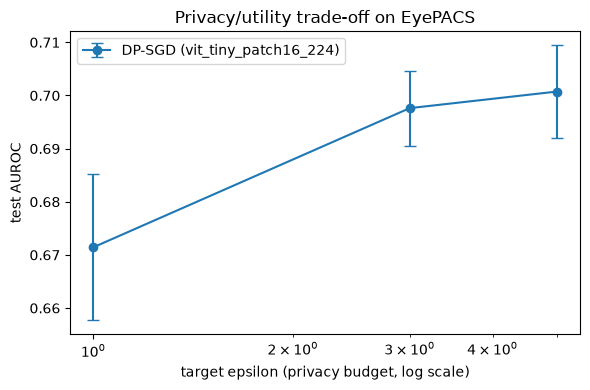

In [21]:
import matplotlib.pyplot as plt

finite_summary = summary[summary["target_epsilon"] != "no_privacy"].copy()
finite_summary["target_epsilon"] = finite_summary["target_epsilon"].astype(float)
finite_summary = finite_summary.sort_values("target_epsilon")

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    finite_summary["target_epsilon"],
    finite_summary["mean_auroc"],
    yerr=finite_summary["std_auroc"],
    marker="o",
    capsize=4,
    label="DP-SGD (vit_tiny_patch16_224)",
)

no_privacy_row = summary[summary["target_epsilon"] == "no_privacy"]
if not no_privacy_row.empty:
    ax.axhline(
        no_privacy_row["mean_auroc"].iloc[0],
        color="gray",
        linestyle="--",
        label="non-private baseline",
    )

ax.set_xscale("log")
ax.set_xlabel("target epsilon (privacy budget, log scale)")
ax.set_ylabel("test AUROC")
ax.set_title("Privacy/utility trade-off on EyePACS")
ax.legend()
fig.tight_layout()
plt.show()

And a per-seed view (a boxplot per epsilon) to check whether variance across seeds shrinks as epsilon grows, as expected when less noise is injected per step:

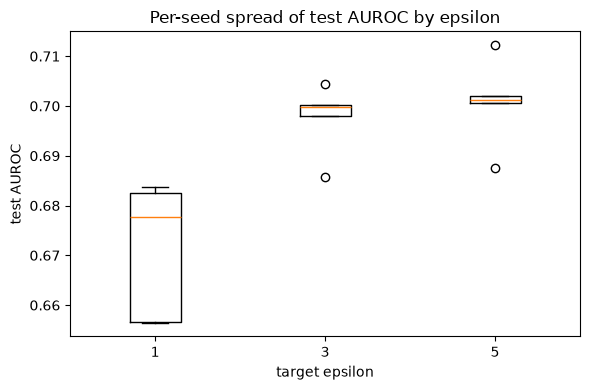

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))

epsilon_order = sorted(
    sweep_df["target_epsilon"].unique(),
    key=lambda value: float("inf") if value == "no_privacy" else float(value),
)
data = [
    sweep_df.loc[sweep_df["target_epsilon"] == eps, "AUROC"].values
    for eps in epsilon_order
]

ax.boxplot(data, tick_labels=epsilon_order)
ax.set_xlabel("target epsilon")
ax.set_ylabel("test AUROC")
ax.set_title("Per-seed spread of test AUROC by epsilon")
fig.tight_layout()
plt.show()

Finally, a quick sanity check that the privacy accountant's actual spent epsilon tracks the requested `--target-epsilon` closely (it won't be exact, since the accountant rounds to a whole number of steps):

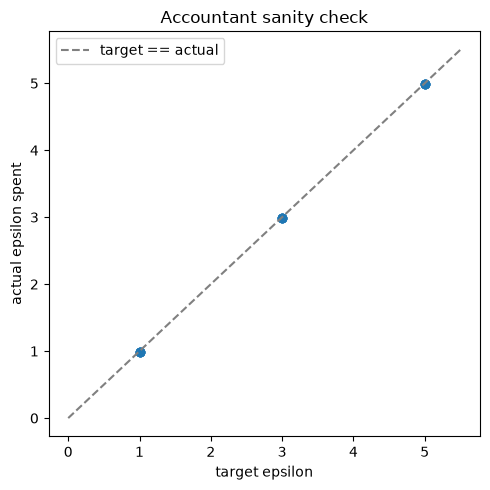

In [15]:
finite_points = sweep_df.dropna(subset=["actual_epsilon"])

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(finite_points["target_epsilon"].astype(float), finite_points["actual_epsilon"])

lims = [0, finite_points["target_epsilon"].astype(float).max() * 1.1]
ax.plot(lims, lims, color="gray", linestyle="--", label="target == actual")

ax.set_xlabel("target epsilon")
ax.set_ylabel("actual epsilon spent")
ax.set_title("Accountant sanity check")
ax.legend()
fig.tight_layout()
plt.show()

## 6. Next steps

- For a real (non-tutorial) experiment, consider a larger/more accurate `timm` backbone, more epochs, and more seeds per configuration to tighten the standard deviation estimate.
- Manually sweeping `learning_rate`, `batch_size`, `epochs`, and `max_grad_norm` by hand (as the cells above do for `epsilon`) does not scale well once you want to tune several hyperparameters at once. 
DPDL also offers a hyperparameter search (`dpdl optimize`, via [Optuna](https://github.com/optuna/optuna)) for this. 
See [tutorial_hpo.ipynb](tutorial_hpo.ipynb) for a hands-on walkthrough on this same EyePACS setup, and [docs/hyperparameter-optimization.md](docs/hyperparameter-optimization.md) for the reference documentation.